<html> <h1 style="font-style:bold; color:blue;"> Neural Computing and Deep Learning </h1> </html>

<html> <h1 style="font-style:italic; color:blue;"> Week-4 </h1> </html>

<html> <h2 style="font-style:italic; color:blue;"> Keras Regression Code Along Project </h2> </html>

Let's now apply our knowledge to a more realistic data set. Here we will also focus on feature engineering and cleaning our data!



## The Data

We will be using data from a Kaggle data set:

https://www.kaggle.com/harlfoxem/housesalesprediction

#### Feature Columns
    
* id - Unique ID for each home sold
* date - Date of the home sale
* price - Price of each home sold
* bedrooms - Number of bedrooms
* bathrooms - Number of bathrooms, where .5 accounts for a room with a toilet but no shower
* sqft_living - Square footage of the apartments interior living space
* sqft_lot - Square footage of the land space
* floors - Number of floors
* waterfront - A dummy variable for whether the apartment was overlooking the waterfront or not
* view - An index from 0 to 4 of how good the view of the property was
* condition - An index from 1 to 5 on the condition of the apartment,
* grade - An index from 1 to 13, where 1-3 falls short of building construction and design, 7 has an average level of construction and design, and 11-13 have a high quality level of construction and design.
* sqft_above - The square footage of the interior housing space that is above ground level
* sqft_basement - The square footage of the interior housing space that is below ground level
* yr_built - The year the house was initially built
* yr_renovated - The year of the house’s last renovation
* zipcode - What zipcode area the house is in
* lat - Lattitude
* long - Longitude
* sqft_living15 - The square footage of interior housing living space for the nearest 15 neighbors
* sqft_lot15 - The square footage of the land lots of the nearest 15 neighbors

### The problem
 - Develop a neural network model to predict the house price based on the above features.


![image.png](attachment:image.png)

![Latitude_and_Longitude_of_the_Earth.ng.png](attachment:Latitude_and_Longitude_of_the_Earth.ng.png)

In [1]:
# Your code to import libraries, numpy, pandas, matplotlib,  seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Import Libraries for Neural Network model development.
# TensorFlow and tf.keras

import tensorflow as tf
from tensorflow import keras

print(tf.__version__)

2.20.0


In [4]:
# Read the data from the file provided

df = pd.read_csv('kc_house_data-1.csv')

df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [5]:
# Your code to print the info of the dataset
# use dataset.info()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

## Exploratory Data Analysis (EDA)

Perform some data analysis using the libraries above.
Visualise the features to understand the problem and use the appropriate features for the model.


In [6]:
# Your code to check if any null value is present in the dataset. Hint - use isnull() in pandas

df.isnull().sum()

,0
id,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0


In [7]:
# Your code to describe the dataset to get imortant properties of it.

df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
id,21613.0,4.580302e+09,2.876566e+09,1.000102e+06,2.123049e+09,3.904930e+09,7.308900e+09,9.900000e+09
price,21613.0,5.400881e+05,3.671272e+05,7.500000e+04,3.219500e+05,4.500000e+05,6.450000e+05,7.700000e+06
bedrooms,21613.0,3.370842e+00,9.300618e-01,0.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,3.300000e+01
bathrooms,21613.0,2.114757e+00,7.701632e-01,0.000000e+00,1.750000e+00,2.250000e+00,2.500000e+00,8.000000e+00
sqft_living,21613.0,2.079900e+03,9.184409e+02,2.900000e+02,1.427000e+03,1.910000e+03,2.550000e+03,1.354000e+04
sqft_lot,21613.0,1.510697e+04,4.142051e+04,5.200000e+02,5.040000e+03,7.618000e+03,1.068800e+04,1.651359e+06
floors,21613.0,1.494309e+00,5.399889e-01,1.000000e+00,1.000000e+00,1.500000e+00,2.000000e+00,3.500000e+00
waterfront,21613.0,7.541757e-03,8.651720e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
view,21613.0,2.343034e-01,7.663176e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00
condition,21613.0,3.409430e+00,6.507430e-01,1.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00


### Let's see how price columns look like i.e. how prices are distributed.


/tmp/ipykernel_16756/1040620539.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price']);


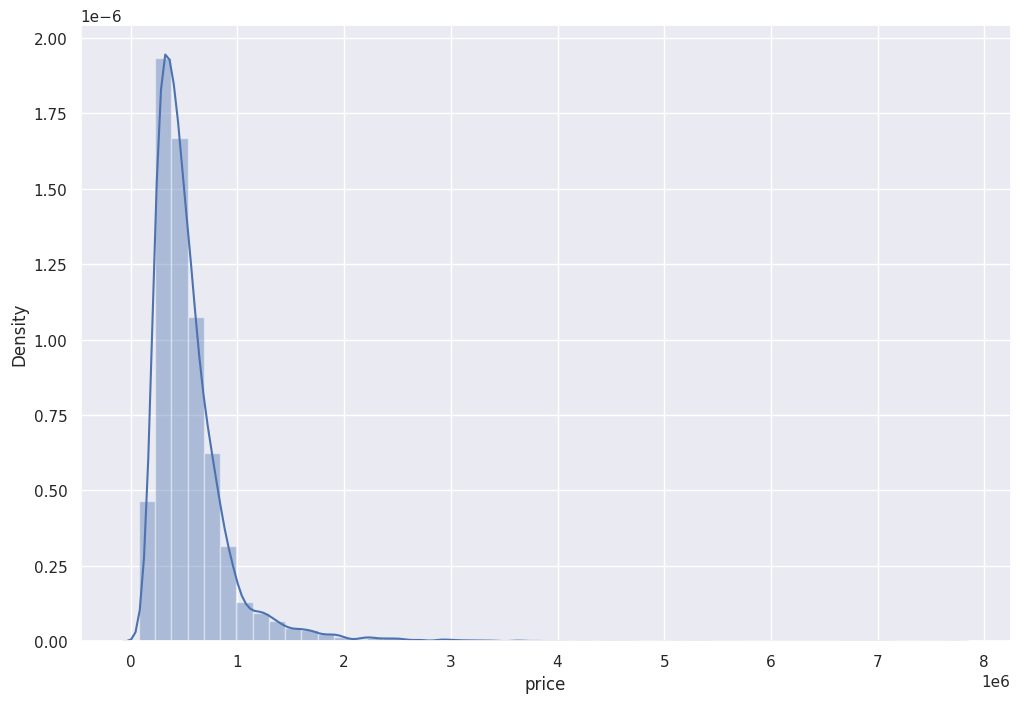

In [8]:
plt.figure(figsize=(12,8))
sns.set_theme()
sns.distplot(df['price']);

#### Let's look at the columns - number of bedroom in more detail

Write code to plot the numbers of bedrooms and the number of times they appear in the data.  

The x-axis contains the number of bedrroms and the y axis will portray the number of times the particular bedroom appears in the column.

Hint - use sns.countplot.  


In [9]:
#sns.countplot?

<Axes: xlabel='bedrooms', ylabel='count'>

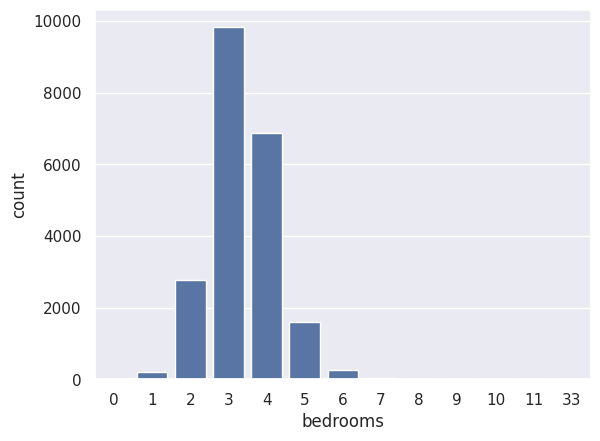

In [10]:
# Your code to plot number of bedrooms and their counts

sns.countplot(x='bedrooms', data=df)

<Axes: xlabel='price', ylabel='sqft_living'>

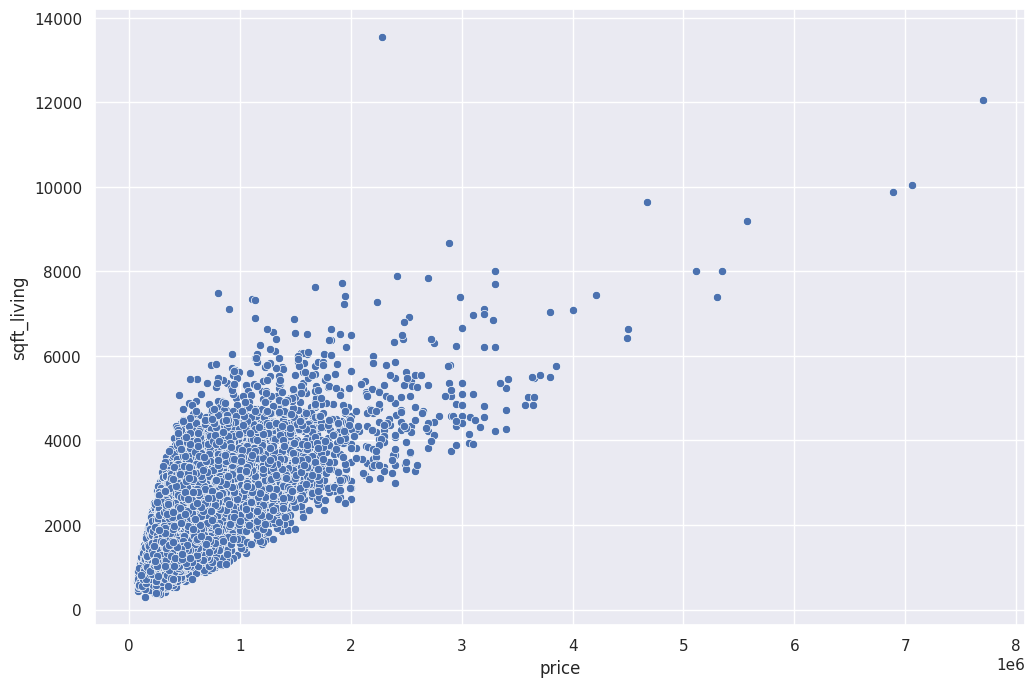

In [11]:
# Plot a scatter plot between the price and sqft_living column.

plt.figure(figsize=(12,8))

sns.scatterplot(x='price',y='sqft_living',data=df)

<Axes: xlabel='bedrooms', ylabel='price'>

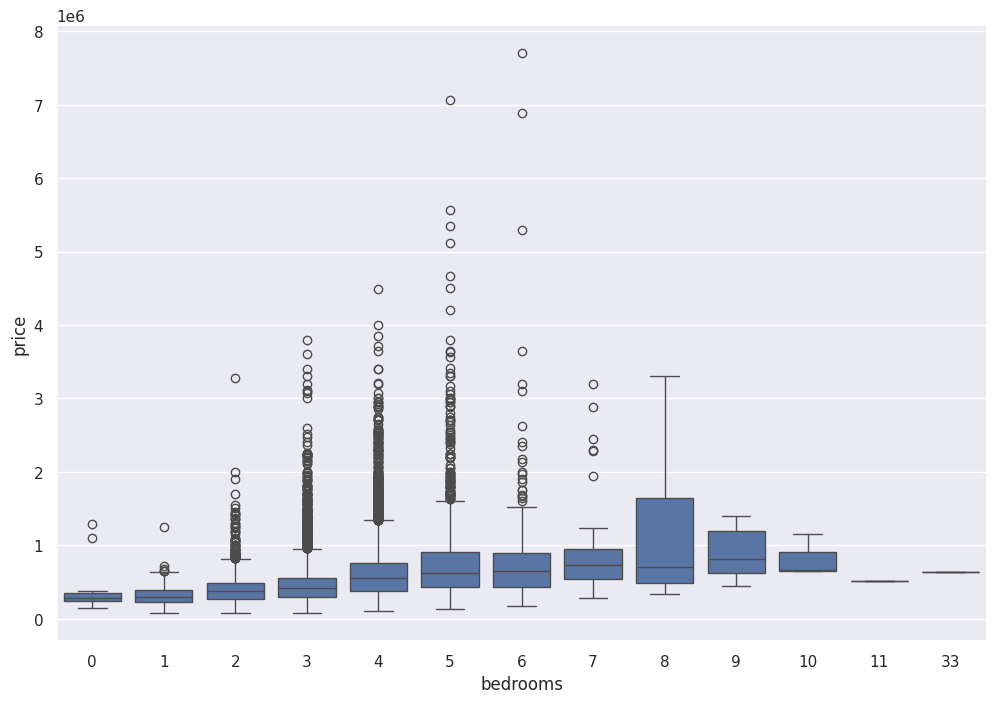

In [12]:
# Plot a box plot between the price and the number of bedrooms

plt.figure(figsize=(12,8))
sns.boxplot(x='bedrooms',y='price',data=df)

## Geographical Properties


#### Visualise scatter plots between price and longitude (long) and latitude (lat) columns.


<Axes: xlabel='long', ylabel='price'>

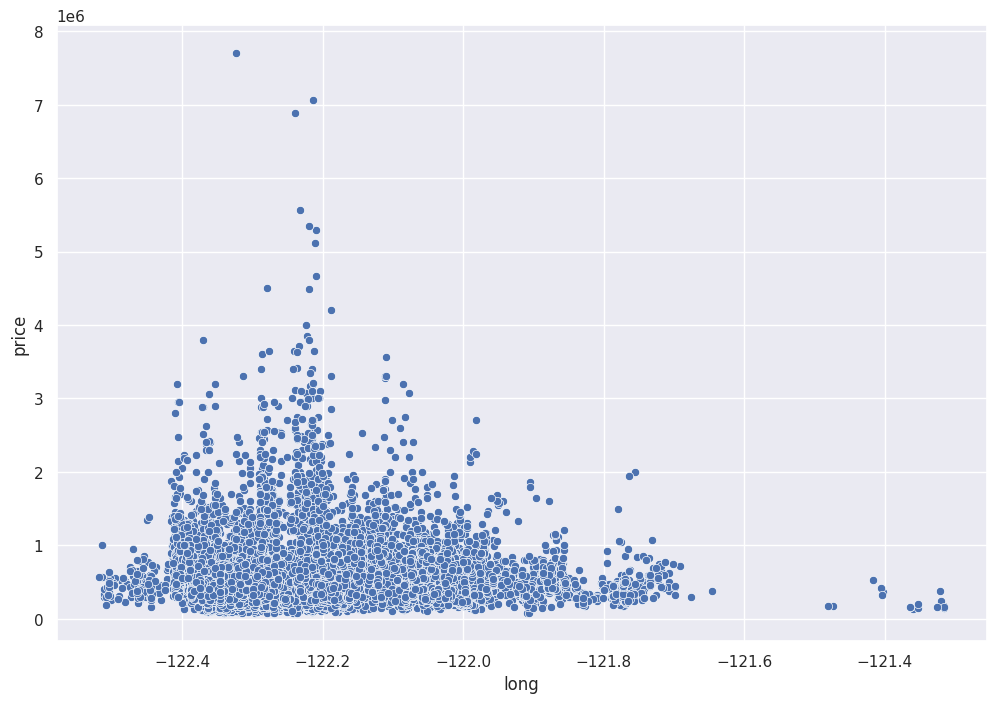

In [13]:
# Visualise a scatter plot between longitude (long) and price columns

plt.figure(figsize=(12,8))
sns.scatterplot(x='long',y='price',data=df)

<Axes: xlabel='price', ylabel='long'>

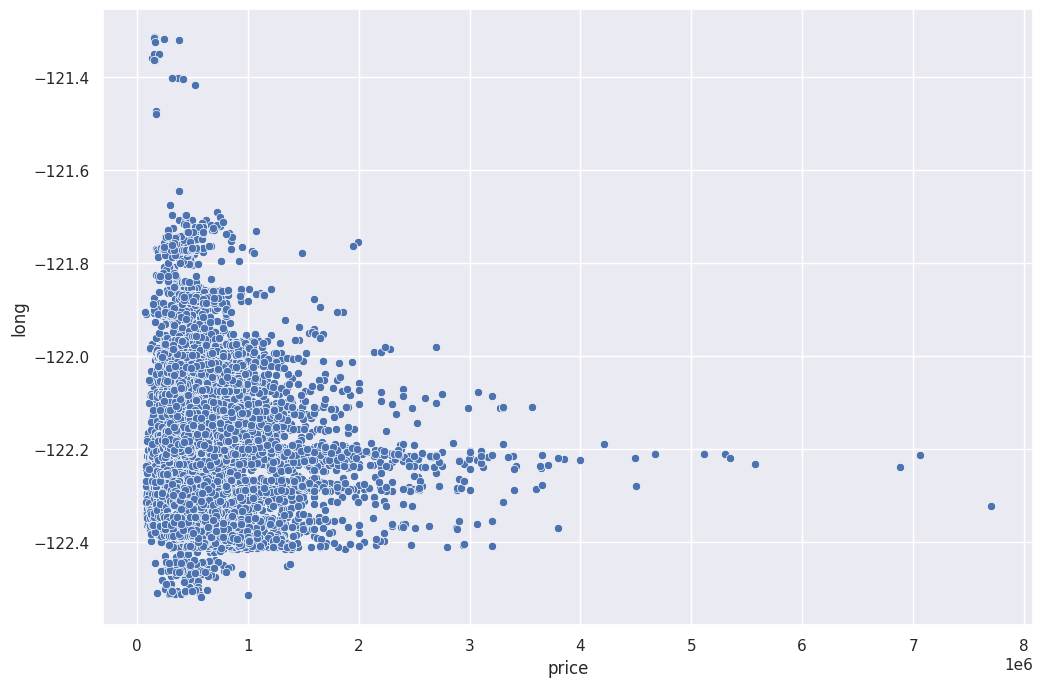

In [14]:
# Change the axes

plt.figure(figsize=(12,8))
sns.scatterplot(x='price',y='long',data=df)

<Axes: xlabel='price', ylabel='lat'>

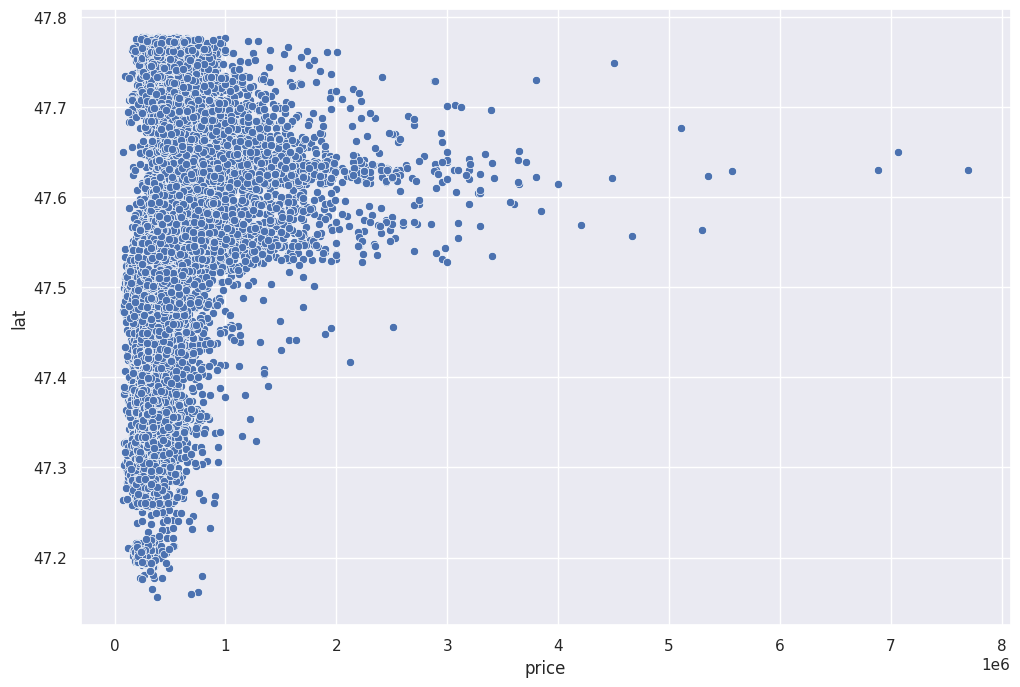

In [15]:
# Your code to visualise a scatter plot between price and latitude(lat) columns

plt.figure(figsize=(12,8))
sns.scatterplot(x='price',y='lat',data=df)

<Axes: xlabel='long', ylabel='lat'>

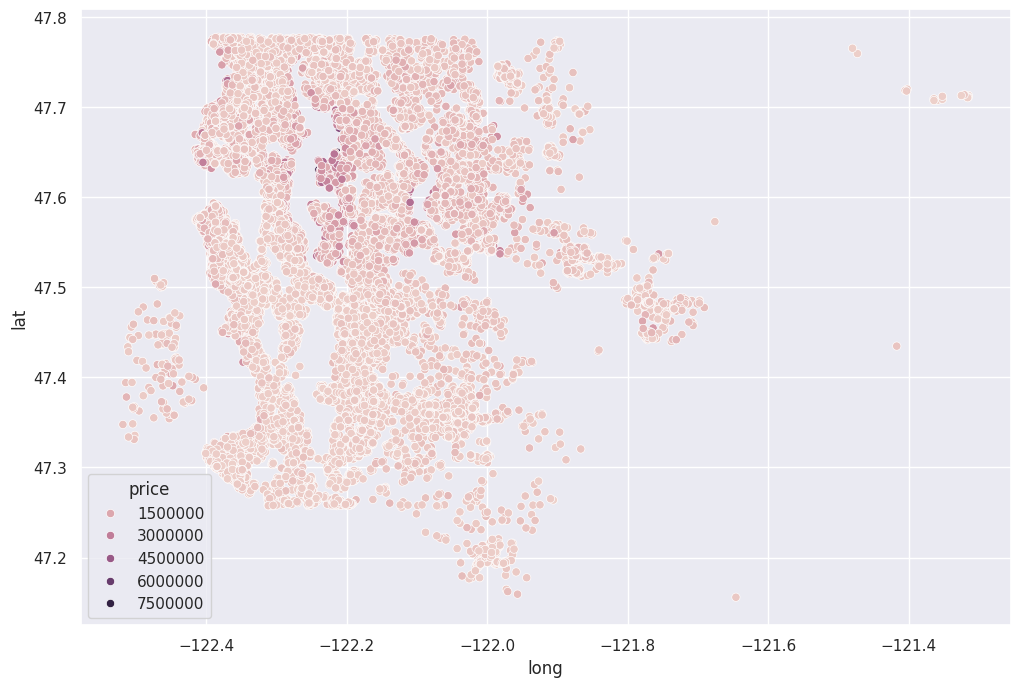

In [16]:
plt.figure(figsize=(12,8))
sns.scatterplot(x='long',y='lat',data=df,hue='price')

#### Compare the graph above with the following maps

![image.png](attachment:image.png)

![image.png](attachment:image.png) ![image-3.png](attachment:image-3.png)

### Sort the values in the dataframe according to price and print first few rows.


In [17]:
#df.sort_values?

In [18]:
# Your code to sort data frame according to the price (ascending order) and see the first few rows.
# Hint - Use df.sort_values and combine it with head()

df.sort_values('price').head(20)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
1149,3421079032,20150217T000000,75000.0,1,0.00,670,43377,1.0,0,0,...,3,670,0,1966,0,98022,47.2638,-121.906,1160,42882
15293,40000362,20140506T000000,78000.0,2,1.00,780,16344,1.0,0,0,...,5,780,0,1942,0,98168,47.4739,-122.280,1700,10387
465,8658300340,20140523T000000,80000.0,1,0.75,430,5050,1.0,0,0,...,4,430,0,1912,0,98014,47.6499,-121.909,1200,7500
16198,3028200080,20150324T000000,81000.0,2,1.00,730,9975,1.0,0,0,...,5,730,0,1943,0,98168,47.4808,-122.315,860,9000
8274,3883800011,20141105T000000,82000.0,3,1.00,860,10426,1.0,0,0,...,6,860,0,1954,0,98146,47.4987,-122.341,1140,11250
2141,1623049041,20140508T000000,82500.0,2,1.00,520,22334,1.0,0,0,...,5,520,0,1951,0,98168,47.4799,-122.296,1572,10570
18468,7999600180,20140529T000000,83000.0,2,1.00,900,8580,1.0,0,0,...,5,900,0,1918,0,98168,47.4727,-122.270,2060,6533
3767,1523049188,20150430T000000,84000.0,2,1.00,700,20130,1.0,0,0,...,6,700,0,1949,0,98168,47.4752,-122.271,1490,18630
10253,2422049104,20140915T000000,85000.0,2,1.00,830,9000,1.0,0,0,...,6,830,0,1939,0,98032,47.3813,-122.243,1160,7680
16714,1322049150,20150305T000000,85000.0,2,1.00,910,9753,1.0,0,0,...,5,910,0,1947,0,98032,47.3897,-122.236,1160,7405


In [19]:
df.sort_values('price',ascending=False).head(20)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
7252,6762700020,20141013T000000,7700000.0,6,8.00,12050,27600,2.5,0,3,...,13,8570,3480,1910,1987,98102,47.6298,-122.323,3940,8800
3914,9808700762,20140611T000000,7062500.0,5,4.50,10040,37325,2.0,1,2,...,11,7680,2360,1940,2001,98004,47.6500,-122.214,3930,25449
9254,9208900037,20140919T000000,6885000.0,6,7.75,9890,31374,2.0,0,4,...,13,8860,1030,2001,0,98039,47.6305,-122.240,4540,42730
4411,2470100110,20140804T000000,5570000.0,5,5.75,9200,35069,2.0,0,0,...,13,6200,3000,2001,0,98039,47.6289,-122.233,3560,24345
1448,8907500070,20150413T000000,5350000.0,5,5.00,8000,23985,2.0,0,4,...,12,6720,1280,2009,0,98004,47.6232,-122.220,4600,21750
1315,7558700030,20150413T000000,5300000.0,6,6.00,7390,24829,2.0,1,4,...,12,5000,2390,1991,0,98040,47.5631,-122.210,4320,24619
1164,1247600105,20141020T000000,5110800.0,5,5.25,8010,45517,2.0,1,4,...,12,5990,2020,1999,0,98033,47.6767,-122.211,3430,26788
8092,1924059029,20140617T000000,4668000.0,5,6.75,9640,13068,1.0,1,4,...,12,4820,4820,1983,2009,98040,47.5570,-122.210,3270,10454
2626,7738500731,20140815T000000,4500000.0,5,5.50,6640,40014,2.0,1,4,...,12,6350,290,2004,0,98155,47.7493,-122.280,3030,23408
8638,3835500195,20140618T000000,4489000.0,4,3.00,6430,27517,2.0,0,0,...,12,6430,0,2001,0,98004,47.6208,-122.219,3720,14592


#### The following code visualises the price intensity with the latitude and longitude for 1% and 99% of the data separately.

#### You need to add comment on each line of the code.


In [20]:
# 1% of the data

len(df)*(0.01)

216.13

In [21]:
df.iloc[216:]

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
216,46100204,20150221T000000,1505000.0,5,3.00,3300,33474,1.0,0,3,...,9,1870,1430,1957,1991,98040,47.5673,-122.210,3836,20953
217,1909600046,20140703T000000,445838.0,3,2.50,2250,5692,2.0,0,0,...,8,2250,0,2000,0,98146,47.5133,-122.379,1320,5390
218,1250202145,20140828T000000,1072000.0,2,2.25,3900,14864,1.0,0,3,...,8,1950,1950,1947,0,98144,47.5884,-122.291,2580,5184
219,7611200125,20141023T000000,467000.0,2,1.50,1320,10800,1.0,0,0,...,8,1320,0,1947,0,98177,47.7145,-122.367,2120,12040
220,5611500140,20140822T000000,686000.0,4,2.50,2760,6440,2.0,0,0,...,10,2760,0,1999,0,98075,47.5836,-122.026,3070,8127
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [22]:
# remove 1% of the most expensive houses and further sorte by decreasing price


non_top_1_perc = df.sort_values('price',ascending=False).iloc[216:]
non_top_1_perc

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
3281,8964800025,20150226T000000,1965000.0,5,3.75,3940,13738,1.5,0,3,...,9,3940,0,1951,0,98004,47.6203,-122.212,2370,13320
12577,2806300065,20150422T000000,1960000.0,4,4.00,4430,31353,2.0,0,0,...,12,4430,0,1998,0,98005,47.6422,-122.157,3900,35237
12283,1923000260,20141015T000000,1959000.0,5,4.50,6200,23373,3.0,0,1,...,11,5050,1150,1988,0,98040,47.5632,-122.215,3700,14486
1152,4055701200,20150421T000000,1955000.0,4,2.75,3120,7898,1.0,1,4,...,8,1560,1560,1963,0,98034,47.7165,-122.259,2630,13868
9175,3124059023,20150213T000000,1955000.0,3,1.75,3330,12566,1.0,1,4,...,8,1940,1390,1960,0,98040,47.5287,-122.220,3730,16560
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8274,3883800011,20141105T000000,82000.0,3,1.00,860,10426,1.0,0,0,...,6,860,0,1954,0,98146,47.4987,-122.341,1140,11250
16198,3028200080,20150324T000000,81000.0,2,1.00,730,9975,1.0,0,0,...,5,730,0,1943,0,98168,47.4808,-122.315,860,9000
465,8658300340,20140523T000000,80000.0,1,0.75,430,5050,1.0,0,0,...,4,430,0,1912,0,98014,47.6499,-121.909,1200,7500
15293,40000362,20140506T000000,78000.0,2,1.00,780,16344,1.0,0,0,...,5,780,0,1942,0,98168,47.4739,-122.280,1700,10387


In [23]:
#sns.scatterplot?

<Axes: xlabel='long', ylabel='lat'>

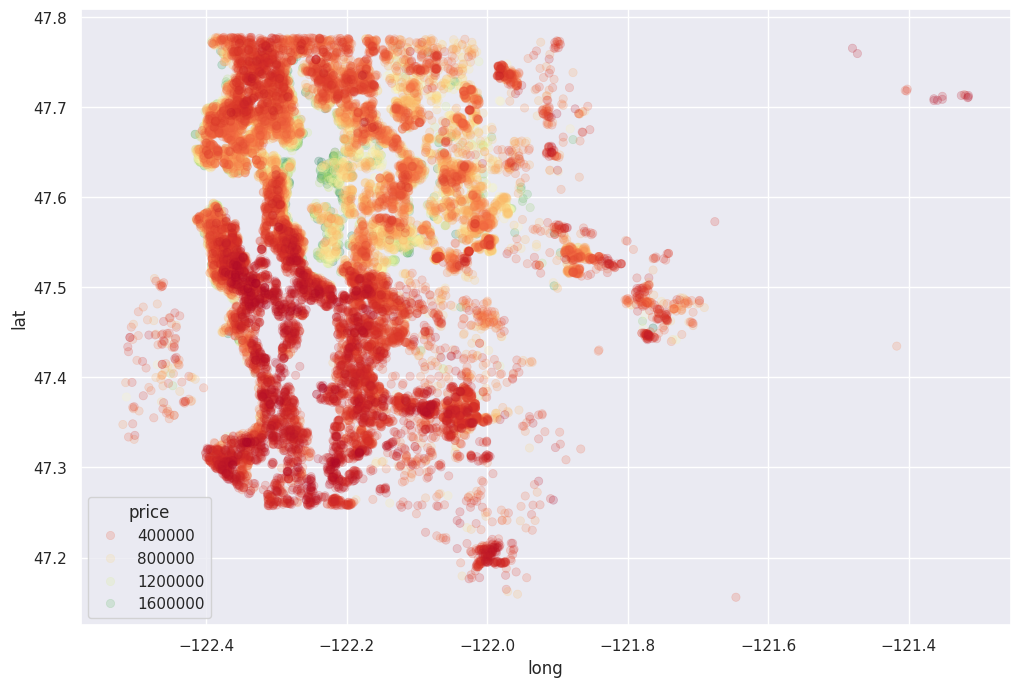

In [24]:
# plotting map of houses sorted by prices (without 1% the most expensive houses)

plt.figure(figsize=(12,8))
sns.scatterplot(x='long',y='lat',
                data=non_top_1_perc,hue='price',
                palette='RdYlGn', edgecolor=None, alpha=0.2)

### Plotting 1% of the most expensive houses


In [25]:
top_1_perc = df.sort_values('price',ascending=False).iloc[:216]
top_1_perc

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
7252,6762700020,20141013T000000,7700000.0,6,8.00,12050,27600,2.5,0,3,...,13,8570,3480,1910,1987,98102,47.6298,-122.323,3940,8800
3914,9808700762,20140611T000000,7062500.0,5,4.50,10040,37325,2.0,1,2,...,11,7680,2360,1940,2001,98004,47.6500,-122.214,3930,25449
9254,9208900037,20140919T000000,6885000.0,6,7.75,9890,31374,2.0,0,4,...,13,8860,1030,2001,0,98039,47.6305,-122.240,4540,42730
4411,2470100110,20140804T000000,5570000.0,5,5.75,9200,35069,2.0,0,0,...,13,6200,3000,2001,0,98039,47.6289,-122.233,3560,24345
1448,8907500070,20150413T000000,5350000.0,5,5.00,8000,23985,2.0,0,4,...,12,6720,1280,2009,0,98004,47.6232,-122.220,4600,21750
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19529,1651500040,20140801T000000,1980000.0,4,4.00,4360,12081,2.0,0,0,...,10,4360,0,2007,0,98004,47.6377,-122.219,2180,10800
16525,2025059026,20150225T000000,1980000.0,4,3.50,4500,44384,1.0,0,0,...,12,3340,1160,1990,0,98004,47.6323,-122.192,2540,26287
7415,5017000470,20140710T000000,1975000.0,6,4.50,4800,9097,2.0,0,0,...,10,3580,1220,2007,0,98112,47.6259,-122.291,2180,6037
17235,1338600225,20140528T000000,1970000.0,8,3.50,4440,6480,2.0,0,3,...,10,3140,1300,1959,0,98112,47.6310,-122.303,4440,8640


<Axes: xlabel='long', ylabel='lat'>

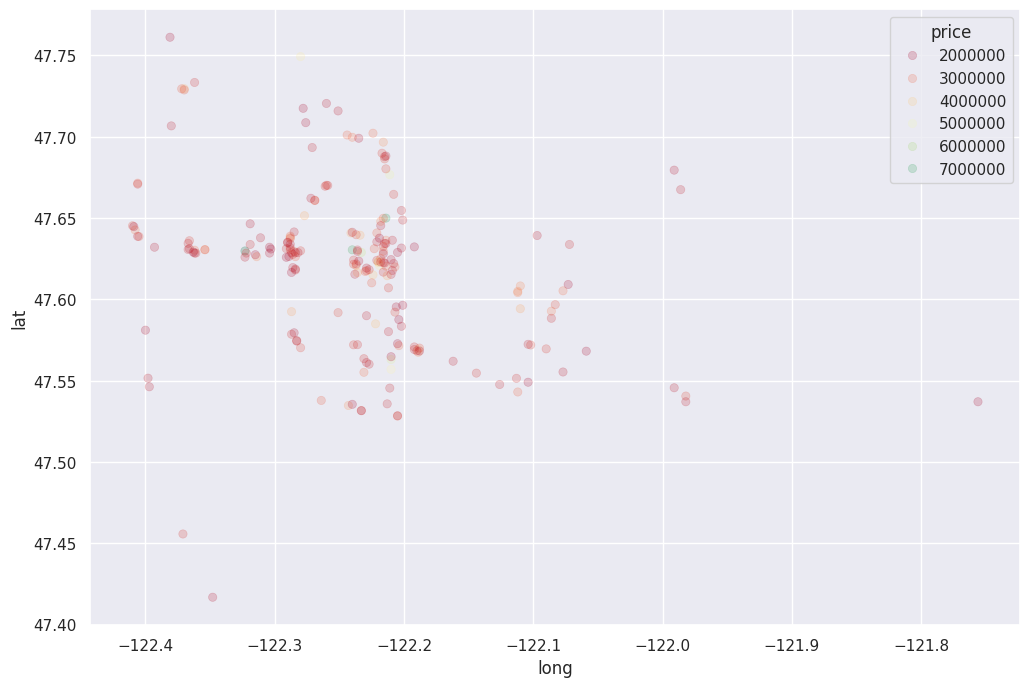

In [26]:
# plotting map of 1% of the most expensive houses

plt.figure(figsize=(12,8))
sns.scatterplot(x='long',y='lat',
                data=top_1_perc,hue='price',
                palette='RdYlGn', edgecolor=None, alpha=0.2)

## Other Features

### Let's have a box plot between waterfront and price.
### Explain what box plot is doing?


![image-2.png](attachment:image-2.png)

<Axes: xlabel='waterfront', ylabel='price'>

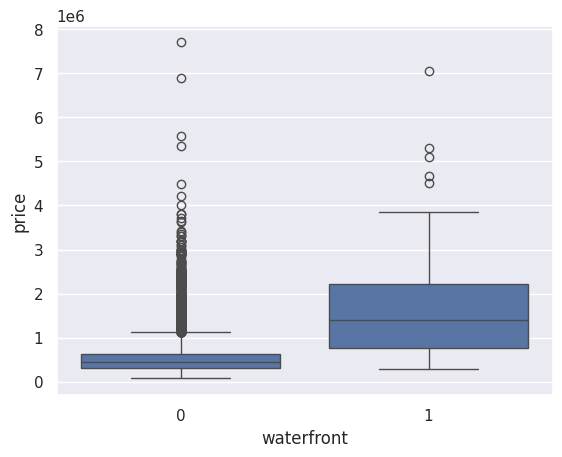

In [27]:
sns.boxplot(x='waterfront',y='price',data=df)

## Working with Feature Data

In [28]:
# Your code to print the first few rows of the data.

df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [29]:
# Your code to print info about the data

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [30]:
# Following code is dropping the column ID.
# Question - why are dropping this column?

# Run the code only once!

df = df.drop('id',axis=1)

### Feature Engineering from Date

Transform the features into useful formats to apply appropriate Deep NN technique!


In [31]:
df['date'] = pd.to_datetime(df['date'])

In [32]:
df['month'] = df['date'].apply(lambda date:date.month)

In [33]:
df['year'] = df['date'].apply(lambda date:date.year)

In [34]:
# Check what the above code is doing

df.head(3)

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,month,year
0,2014-10-13,221900.0,3,1.00,1180,5650,1.0,0,0,3,...,0,1955,0,98178,47.5112,-122.257,1340,5650,10,2014
1,2014-12-09,538000.0,3,2.25,2570,7242,2.0,0,0,3,...,400,1951,1991,98125,47.7210,-122.319,1690,7639,12,2014
2,2015-02-25,180000.0,2,1.00,770,10000,1.0,0,0,3,...,0,1933,0,98028,47.7379,-122.233,2720,8062,2,2015


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           21613 non-null  datetime64[ns]
 1   price          21613 non-null  float64       
 2   bedrooms       21613 non-null  int64         
 3   bathrooms      21613 non-null  float64       
 4   sqft_living    21613 non-null  int64         
 5   sqft_lot       21613 non-null  int64         
 6   floors         21613 non-null  float64       
 7   waterfront     21613 non-null  int64         
 8   view           21613 non-null  int64         
 9   condition      21613 non-null  int64         
 10  grade          21613 non-null  int64         
 11  sqft_above     21613 non-null  int64         
 12  sqft_basement  21613 non-null  int64         
 13  yr_built       21613 non-null  int64         
 14  yr_renovated   21613 non-null  int64         
 15  zipcode        2161

<Axes: xlabel='year', ylabel='price'>

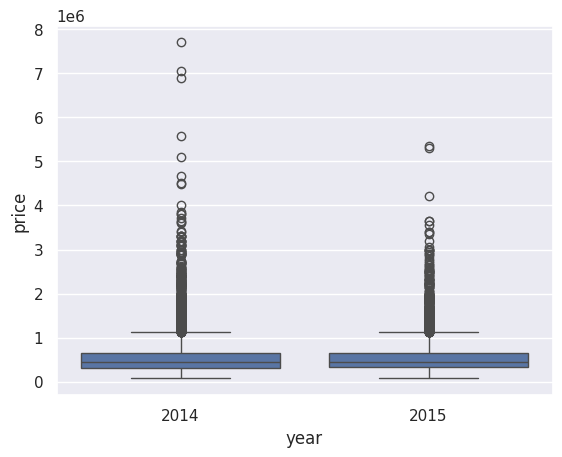

In [36]:
# Visualise boxplot between year and price

sns.boxplot(x='year',y='price',data=df)

<Axes: xlabel='month', ylabel='price'>

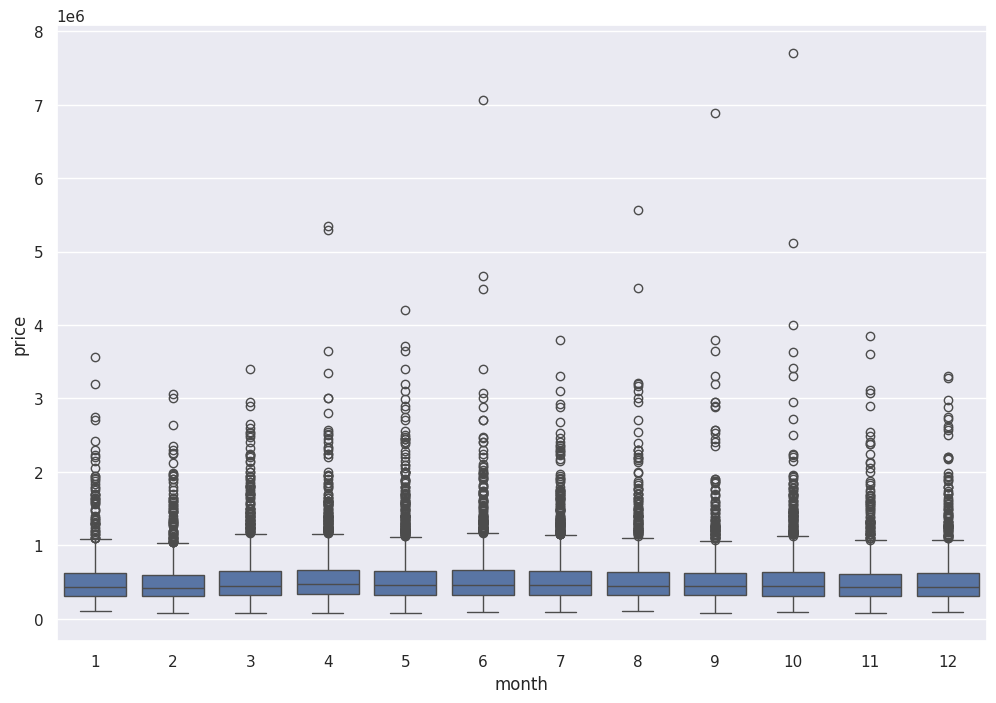

In [37]:
# Your code to visualise boxplot between month and price

plt.figure(figsize=(12,8))
sns.boxplot(x='month',y='price',data=df)

<Axes: xlabel='month'>

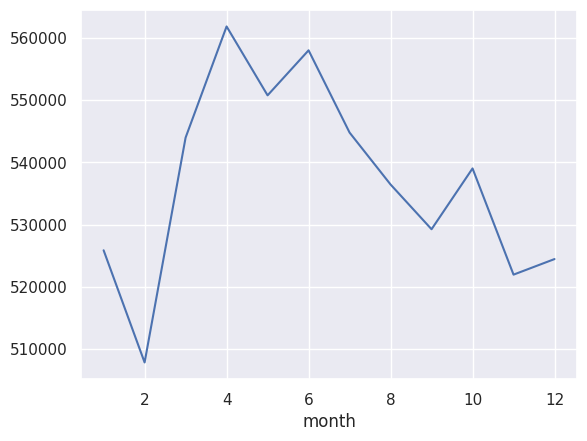

In [38]:
# Approximation of maximum prices by months


df.groupby('month').mean()['price'].plot()

In [39]:
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15', 'month', 'year'],
      dtype='object')

In [40]:
# Should we remove zipcode? If so, remove it.

# May be worth considering to remove this or feature engineer categories from it


df['zipcode'].value_counts()

,count
zipcode,
98103,602
98038,590
98115,583
98052,574
98117,553
...,...
98102,105
98010,100
98024,81


In [41]:
# We do not need the 'date' column anymore

df = df.drop('date',axis=1)


In [42]:
# Your code to remove zip code
# Hint - Use df.drop

df = df.drop('zipcode',axis=1)

In [43]:
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,lat,long,sqft_living15,sqft_lot15,month,year
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,47.5112,-122.257,1340,5650,10,2014
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,47.7210,-122.319,1690,7639,12,2014
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,47.7379,-122.233,2720,8062,2,2015
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,47.5208,-122.393,1360,5000,12,2014
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,47.6168,-122.045,1800,7503,2,2015


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          21613 non-null  float64
 1   bedrooms       21613 non-null  int64  
 2   bathrooms      21613 non-null  float64
 3   sqft_living    21613 non-null  int64  
 4   sqft_lot       21613 non-null  int64  
 5   floors         21613 non-null  float64
 6   waterfront     21613 non-null  int64  
 7   view           21613 non-null  int64  
 8   condition      21613 non-null  int64  
 9   grade          21613 non-null  int64  
 10  sqft_above     21613 non-null  int64  
 11  sqft_basement  21613 non-null  int64  
 12  yr_built       21613 non-null  int64  
 13  yr_renovated   21613 non-null  int64  
 14  lat            21613 non-null  float64
 15  long           21613 non-null  float64
 16  sqft_living15  21613 non-null  int64  
 17  sqft_lot15     21613 non-null  int64  
 18  month 

In [45]:
# could make sense due to scaling, higher should correlate to more value


df['yr_renovated'].value_counts()

,count
yr_renovated,
0,20699
2014,91
2013,37
2003,36
2005,35
...,...
1948,1
1951,1
1959,1


In [46]:
df['sqft_basement'].value_counts()

,count
sqft_basement,
0,13126
600,221
700,218
500,214
800,206
...,...
176,1
225,1
1275,1


## Scaling and Train Test Split

Scikit-Learn is used to split out the train-test library.

First separate input and output. Input will be stored in the variable X and output in variable y.


In [47]:
df.shape

(21613, 20)

In [48]:
# Store all columns except the price column in variable X.


X = df.drop('price',axis=1)

In [49]:
X.shape

(21613, 19)

In [50]:
# Store output (price column) in variable y

y = df['price']
y.shape

(21613,)

In [51]:
from sklearn.model_selection import train_test_split

In [52]:
#train_test_split?

In [53]:
# Code to separate X and y into X_train, X_test, y_train, y_test i.e. getting training and testing set for the model.

# You can choose your unique test data size as a percentage of the original dataset.
# It is better to consider the range from 15 to 35%


X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state=101)

# random_state - int for reproducible output across multiple function calls

In [54]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(15129, 19) (6484, 19) (15129,) (6484,)


### Scaling

Features are scaled to be in a proper range to be useful for modeling. Scaling converts all values between 0-1.


In [55]:
from sklearn.preprocessing import MinMaxScaler

In [56]:
scaler = MinMaxScaler()

![image.png](attachment:image.png)

fit_transform() is used on the training data so that we can scale the training data and also learn the scaling parameters of that data, such as the mean and variance of the features of the training set. These learned and fixed parameters are then used to scale our test data with the transform() function.


In [57]:
X_train= scaler.fit_transform(X_train)

In [58]:
X_test = scaler.transform(X_test)

In [59]:
# Your code to print shapes of X_train, X_test, y_train, y_test and see if shapes are okay.

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

# The shape shouldn't be changed

(15129, 19) (6484, 19) (15129,) (6484,)


## Creating a Model

Build a Deep NN model with appropriate layers using Keras.  

In [60]:
input_shape=(X_train.shape[1],)
input_shape

(19,)

In [61]:
# Your code to build MLP neural network model.

# Develop your own Neural Network model with suitable numbers of input, output, and any number of hidden layers.
# Use the code for input layer: input_shape=(X_train.shape[1],)
# Since we are predicting a value, the number of neurons in the output layer should be one.

# You must create your own neural network!

model = keras.Sequential([
    keras.layers.Dense(152, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.Dense(76, activation='relu'),
    keras.layers.Dense(38, activation='relu'),
    keras.layers.Dense(19, activation='relu'),
    keras.layers.Dense(1)
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [62]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 152)            │         3,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 76)             │        11,628 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 38)             │         2,926 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 19)             │           741 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            20 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,355 (71.70 KB)

 Trainable params: 18,355 (71.70 KB)

 Non-trainable params: 0 (0.00 B)

None


## Training the Model

#### Write the code to train the neural network model. Use the following of your choice:

1.   Optimisation method
2.   Batch size
3.   Number of epochs.

Test for various optimizers and check which one performs better in terms of loss function = 'mse'.

Use following APIs
* https://keras.io/api/optimizers/
* https://keras.io/api/losses/regression_losses/
* https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics
* https://keras.io/api/models/model_training_apis/


In [63]:
# ! add your chosen optimiser !
# model.compile(optimizer='ADD HERE YOUR CHOSEN OPTIMISER', loss='mse')

model.compile(optimizer='adam', loss='mse')

In [64]:
history = model.fit(X_train, y_train, batch_size=128, epochs=200,  verbose=1)

Epoch 1/200
119/119 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 422902431744.0000
Epoch 2/200
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 345927811072.0000
Epoch 3/200
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 111515803648.0000
Epoch 4/200
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 95149776896.0000
Epoch 5/200
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 91212808192.0000
Epoch 6/200
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 87027728384.0000
Epoch 7/200
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 82556182528.0000
Epoch 8/200
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 77617422336.0000
Epoch 9/200
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 72289632256.0000
Epoch 10/200
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 67010396160.0000
Epoch 11/200
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 61862739968.0000
Epoch 12/200
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 57748856832.0000
Epoch 13/200
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - lo

#### Following code gets the history of losses at every epoch.


In [65]:
losses = pd.DataFrame(model.history.history)

<Axes: >

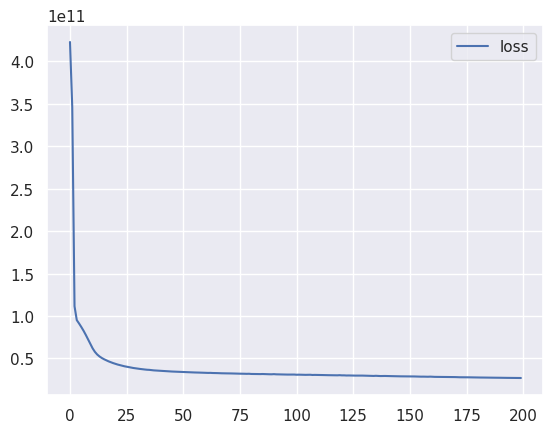

In [66]:
losses.plot()

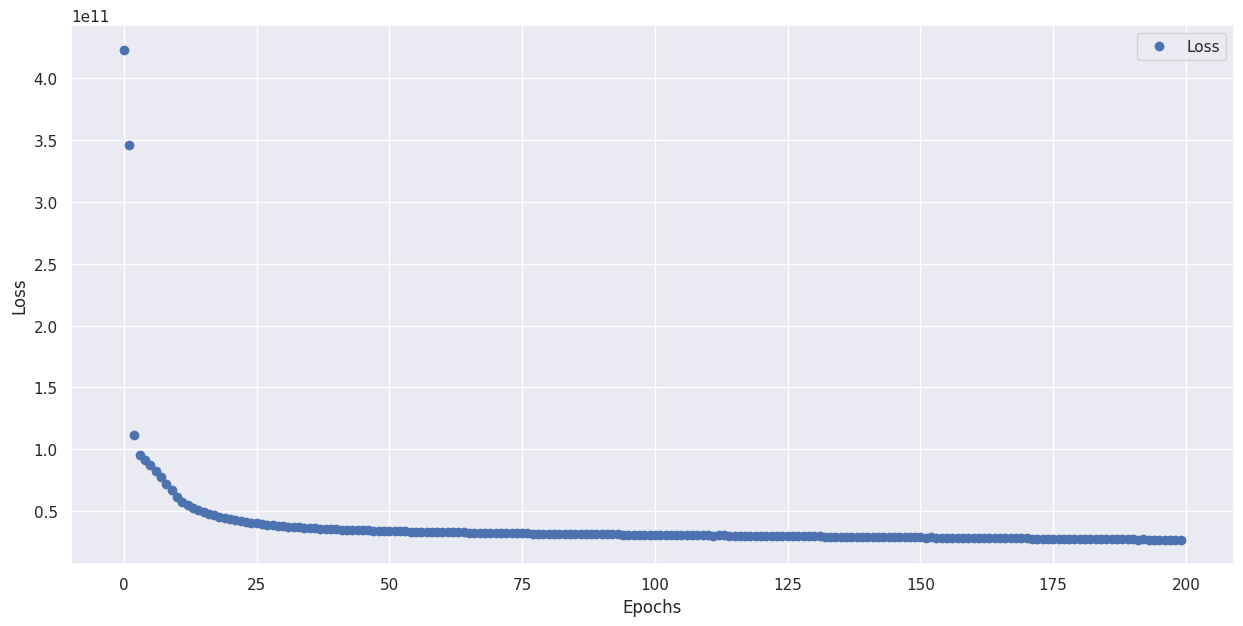

In [67]:
# Losses graphs during training

history_dict = history.history
Loss = losses['loss']
plt.figure(num=1, figsize=(15,7))
plt.plot(Loss, 'bo', label='Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [94]:
# Accuracy graphs during training

import matplotlib.pyplot as plt

history_dict = history.history
print(history_dict)

{'loss': [422902431744.0, 345927811072.0, 111515803648.0, 95149776896.0, 91212808192.0, 87027728384.0, 82556182528.0, 77617422336.0, 72289632256.0, 67010396160.0, 61862739968.0, 57748856832.0, 54670053376.0, 52410331136.0, 50608283648.0, 49113796608.0, 47806947328.0, 46609104896.0, 45557415936.0, 44558577664.0, 43632287744.0, 42839777280.0, 42140942336.0, 41445007360.0, 40790429696.0, 40258297856.0, 39722319872.0, 39135387648.0, 38741504000.0, 38328213504.0, 37923573760.0, 37611479040.0, 37231587328.0, 36976902144.0, 36692365312.0, 36551970816.0, 36230639616.0, 35939106816.0, 35760951296.0, 35517169664.0, 35345719296.0, 35213471744.0, 35043627008.0, 34901811200.0, 34772254720.0, 34588692480.0, 34470551552.0, 34363772928.0, 34158794752.0, 34119348224.0, 33955590144.0, 33867915264.0, 33806837760.0, 33748342784.0, 33532702720.0, 33477500928.0, 33449074688.0, 33333772288.0, 33214619648.0, 33162553344.0, 33058437120.0, 32956131328.0, 33007693824.0, 32847595520.0, 32844500992.0, 32731633664.

# Evaluation on Test Data

https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics

Scikit-Learn has metrics to evaluate the performance.


In [68]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,explained_variance_score

#### Next, we will test the performance of our model by predicting on test dataset X_test.


In [69]:
# Your code to print X_test and see how test data looks like:

print(X_test)

[[0.18181818 0.125      0.05735849 ... 0.010289   0.         1.        ]
 [0.36363636 0.28125    0.13207547 ... 0.00909894 0.27272727 1.        ]
 [0.36363636 0.3125     0.16679245 ... 0.00418246 0.09090909 1.        ]
 ...
 [0.27272727 0.25       0.17584906 ... 0.00821673 0.90909091 0.        ]
 [0.18181818 0.125      0.04603774 ... 0.0044122  0.27272727 1.        ]
 [0.36363636 0.4375     0.24226415 ... 0.01018447 0.72727273 0.        ]]


In [70]:
X_test.shape

(6484, 19)

### Following you will predict the output based on the input data X_test.


Lonk to API - https://keras.io/api/models/model_training_apis/#predict-method

In [71]:
# Make predictions using (model.predict (<input_data>) method ).
# Store the predictions in the variable predictions


predictions = model.predict(X_test)

203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


### Following code will test the error in the predicted values.
### Error is the difference between the predictions you made and real values (y_test)


In [72]:
print(mean_absolute_error(y_test, predictions))

103805.22563714528


In [73]:
#print (np.sqrt(mean_squared_error())) # There is an error in this line. Fix the error.

print(np.sqrt(mean_squared_error(y_test,predictions)))

165467.5551674996


In [74]:
explained_variance_score(y_test,predictions)

0.8060744043013872

In [75]:
df['price'].mean()

np.float64(540088.1417665294)

In [76]:
df['price'].median()

450000.0

In [77]:
# The following code plots the predicted values in a scatter plot.
# We have also plotted the perfect predictions.


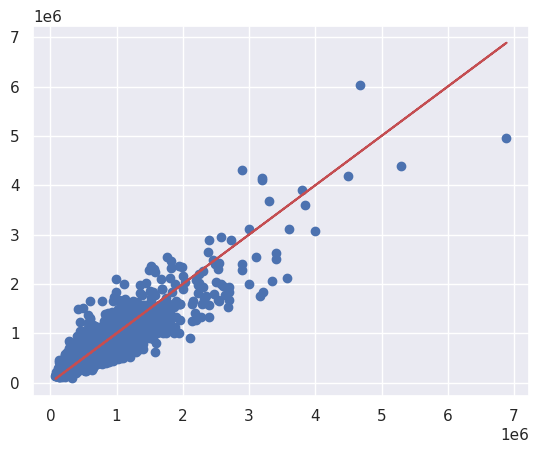

In [78]:
# Our predictions
plt.scatter(y_test, predictions)

# Perfect predictions
plt.plot(y_test, y_test,'r')

In [79]:
# In the following code, we have plotted the error i.e.
# the difference between the actual and predicted values.


In [80]:
errors = y_test.values.reshape(6484, 1) - predictions

/tmp/ipykernel_16756/2392254718.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(errors)


<Axes: ylabel='Density'>

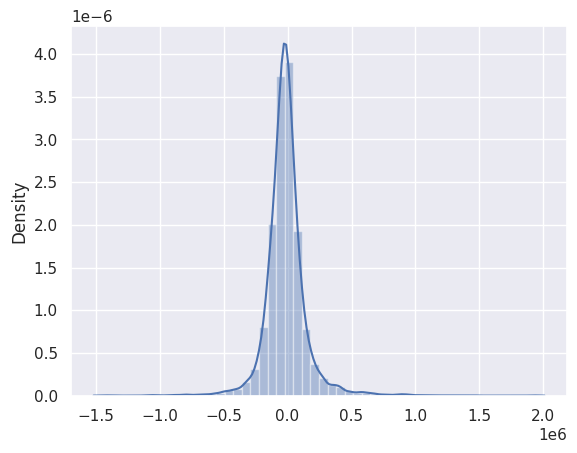

In [81]:
sns.distplot(errors)


### Following code makes prediction on a brand new house. Comment each line of the code.

Try predicting price for a new home.


In [82]:
single_house = df.drop('price',axis=1).iloc[0]

In [83]:
df['price'].iloc[0]

np.float64(221900.0)

In [84]:
single_house

,0
bedrooms,3.0000
bathrooms,1.0000
sqft_living,1180.0000
sqft_lot,5650.0000
floors,1.0000
waterfront,0.0000
view,0.0000
condition,3.0000
grade,7.0000
sqft_above,1180.0000


In [85]:
single_house.size

19

In [86]:
single_house = scaler.transform(single_house.values.reshape(-1, 19))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [87]:
#print(single_house)

single_house

array([[0.27272727, 0.125     , 0.06716981, 0.00310751, 0.        ,
        0.        , 0.        , 0.5       , 0.5       , 0.09758772,
        0.        , 0.47826087, 0.        , 0.57149751, 0.21760797,
        0.16193426, 0.00573322, 0.81818182, 0.        ]])

In [88]:
model.predict(single_house)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


array([[291820.72]], dtype=float32)

In [89]:
df.iloc[0]

,0
price,221900.0000
bedrooms,3.0000
bathrooms,1.0000
sqft_living,1180.0000
sqft_lot,5650.0000
floors,1.0000
waterfront,0.0000
view,0.0000
condition,3.0000
grade,7.0000


In [90]:
err = int(model.predict(single_house)) - df['price'].iloc[0]

print( 'absolute prediction error = ', err, ' $')
print( 'relative prediction error = ', err / df['price'].iloc[0] *100 , ' %')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
absolute prediction error =  69920.0  $
relative prediction error =  31.509689049121224  %


/tmp/ipykernel_16756/3458571219.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  err = int(model.predict(single_house)) - df['price'].iloc[0]


In [91]:
err = int(model.predict(single_house)) - df['price'].iloc[0]

print( 'absolute prediction error = ', err, ' $')
print( 'relative prediction error = ', err / df['price'].iloc[0] *100 , ' %')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
absolute prediction error =  69920.0  $
relative prediction error =  31.509689049121224  %


/tmp/ipykernel_16756/3458571219.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  err = int(model.predict(single_house)) - df['price'].iloc[0]


<html> <h2 style="font-style:bold; color:red;"> Lab Logbook requirements </h2> </html>

### Please record the plot of the  model's  loss after every epoch and a summary in lab logbook. You can obtain the model summary using the model.summary() method. The API for obtaining the model summary is defined in the following link:

### https://keras.io/api/models/model/#summary-method

### Ensure that no code or other information is added to the logbook and that only required information is present.  Marks will not be awarded if anything else is found in the logbook or instructions are not clearly followed.


<html> <h3 style="font-style:bold; color:blue;"> Try different optimisations like changing model architecture, activation functions, training parameters. </h3> </html>
